Data Diet Rekomendasi 
sumber: https://www.kaggle.com/datasets/fritze/informasi-nilai-gizi-indonesia

Pertanyaan Bisnis:
- Bagaimana distribusi kandungan gizi pada makanan dalam database?
- Kelompok mana yang memiliki kebutuhan gizi paling tinggi dan paling rendah?
- Seberapa besar kesenjangan antara kandungan gizi makanan dengan kebutuhan AKG harian pengguna?

LIBRARY

In [55]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

GATHERING DATA

In [56]:
nutrition_df = pd.read_csv("https://raw.githubusercontent.com/ekasaaa/analisis-dataset-gizi/refs/heads/main/nilai-gizi.csv", sep=";")
nutrition_df.head()

,Nama_Makanan,Produsen,Porsi,Energi (kkal),Protein (g),Karbohidrat (g),Lemak (g),Gula (g),Natrium (mg),Serat (g),...,Natrium,Protein,Karbohidrat_Total,Energi,Lemak_Total,Serat_Pangan,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,Ikan sunu,asin,mentah,Tidak Diketahui,20.30 g,199.0,34.1,7.1,3.8,0.0,...,25.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,Soto pekalongan,masakan,Tidak Diketahui,1.30 g,94.0,3.0,5.1,6.8,0.0,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,Marie duo,Tidak Diketahui,1 g,15.0,1.0,14.0,3.5,5.0,85.0,1.0,...,6.00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,Kaparende,sayur,Tidak Diketahui,1.30 g,38.0,2.4,2.6,2.0,0.0,170.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,Kacang lebui / iris,Tidak Diketahui,3.60 g,346.0,16.5,66.6,1.5,0.0,17.0,37.3,...,0.00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [57]:
#PARSING
nutrition_df.columns

Index(['Nama_Makanan', 'Produsen', 'Porsi', 'Energi (kkal)', 'Protein (g)',
       'Karbohidrat (g)', 'Lemak (g)', 'Gula (g)', 'Natrium (mg)', 'Serat (g)',
       'Persentase_AKG_Energi', 'Persentase_AKG_Protein',
       'Persentase_AKG_Karbohidrat', 'Persentase_AKG_Lemak',
       'Persentase_AKG_Natrium', 'Lemak_Jenuh', 'Natrium', 'Protein',
       'Karbohidrat_Total', 'Energi', 'Lemak_Total', 'Serat_Pangan',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')

ASSESSING DATA

In [58]:
#cek tipe data dan jumlah data yang kosong
nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nama_Makanan                1651 non-null   object 
 1   Produsen                    1651 non-null   object 
 2   Porsi                       1651 non-null   object 
 3   Energi (kkal)               1651 non-null   object 
 4   Protein (g)                 1651 non-null   object 
 5   Karbohidrat (g)             1651 non-null   object 
 6   Lemak (g)                   1651 non-null   object 
 7   Gula (g)                    1651 non-null   float64
 8   Natrium (mg)                1651 non-null   float64
 9   Serat (g)                   1651 non-null   float64
 10  Persentase_AKG_Energi       1651 non-null   float64
 11  Persentase_AKG_Protein      1651 non-null   float64
 12  Persentase_AKG_Karbohidrat  1651 non-null   float64
 13  Persentase_AKG_Lemak        1651 

In [59]:
#Mengecek missing values pada dataset nutrition_df
nutrition_df.isna().sum()

Nama_Makanan                     0
Produsen                         0
Porsi                            0
Energi (kkal)                    0
Protein (g)                      0
Karbohidrat (g)                  0
Lemak (g)                        0
Gula (g)                         0
Natrium (mg)                     0
Serat (g)                        0
Persentase_AKG_Energi            0
Persentase_AKG_Protein           0
Persentase_AKG_Karbohidrat       0
Persentase_AKG_Lemak             0
Persentase_AKG_Natrium           0
Lemak_Jenuh                      0
Natrium                          0
Protein                          0
Karbohidrat_Total                0
Energi                           0
Lemak_Total                      0
Serat_Pangan                     0
Unnamed: 22                   1196
Unnamed: 23                   1586
Unnamed: 24                   1641
Unnamed: 25                   1649
dtype: int64

In [60]:
#Mengecek duplikasi tabel nutrition_df
print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


In [61]:
#Mengecek menggunakan method describe
nutrition_df.describe()

,Gula (g),Natrium (mg),Serat (g),Persentase_AKG_Energi,Persentase_AKG_Protein,Persentase_AKG_Karbohidrat,Persentase_AKG_Lemak,Persentase_AKG_Natrium,Lemak_Jenuh,Natrium,Protein,Karbohidrat_Total,Energi,Lemak_Total,Serat_Pangan,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,455.0,65.0,10.0,2.0
mean,5.924906,99.068565,23.429085,12.353998,11.175542,10.120218,11.795845,8.384155,3.215530,4.300485,4.094482,2.468280,3.687462,5.227135,1.013931,0.0,0.0,0.0,0.0
std,13.792322,407.541251,106.819370,51.215859,32.562132,11.118718,18.874163,27.627000,10.961959,14.592509,12.379304,5.861247,7.990628,14.224772,6.354129,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.000000,0.000000,0.000000,2.200000,1.670000,3.330000,1.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.400000,0.000000,0.700000,5.580000,5.000000,6.460000,5.220000,0.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,6.000000,34.000000,4.000000,12.490000,13.330000,14.000000,14.930000,6.000000,0.270000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,0.0,0.0,0.0,0.0
max,201.000000,11998.000000,1724.000000,1068.000000,1081.000000,123.830000,182.090000,799.870000,225.000000,136.000000,132.000000,57.000000,80.000000,183.000000,147.000000,0.0,0.0,0.0,0.0


INSIGHT :
- terdapat missing value di beberapa kolonm 'unnamed'
- beberapa kolom nutrisi seperti Protein (g), Karbohidrat (g), Lemak (g), dan Porsi terdeteksi bertipe data object yang seharusnya bertipe data float/int
- tidak terdapat duplikasi dalam data ini

CLEANING DATA

In [62]:
#mengubah tulisan "tidak diketahui" menjadi NaN agar bisa diproses
nutrition_df['Porsi'] = nutrition_df['Porsi'].replace('tidak diketahui', np.nan)

#Ambil angkanya saja (membuang 'g', 'ml', dll)
#Regex ini akan mengambil angka desimal maupun bulat
nutrition_df['Porsi'] = nutrition_df['Porsi'].str.extract('(\d+\.?\d*)').astype(float)

#Isi data yang kosong (NaN) tadi dengan nilai tengah (Median)
median_porsi = nutrition_df['Porsi'].median()
nutrition_df['Porsi'] = nutrition_df['Porsi'].fillna(median_porsi)

print("Tipe data Porsi sekarang:", nutrition_df['Porsi'].dtype)

Tipe data Porsi sekarang: float64


In [63]:
#cek
nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nama_Makanan                1651 non-null   object 
 1   Produsen                    1651 non-null   object 
 2   Porsi                       1651 non-null   float64
 3   Energi (kkal)               1651 non-null   object 
 4   Protein (g)                 1651 non-null   object 
 5   Karbohidrat (g)             1651 non-null   object 
 6   Lemak (g)                   1651 non-null   object 
 7   Gula (g)                    1651 non-null   float64
 8   Natrium (mg)                1651 non-null   float64
 9   Serat (g)                   1651 non-null   float64
 10  Persentase_AKG_Energi       1651 non-null   float64
 11  Persentase_AKG_Protein      1651 non-null   float64
 12  Persentase_AKG_Karbohidrat  1651 non-null   float64
 13  Persentase_AKG_Lemak        1651 

In [64]:
#Menghapus kolom Unnamed yang tidak diperlukan
nutrition_df.drop(nutrition_df.columns[nutrition_df.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)

In [65]:
#cek
nutrition_df.isna().sum()

Nama_Makanan                  0
Produsen                      0
Porsi                         0
Energi (kkal)                 0
Protein (g)                   0
Karbohidrat (g)               0
Lemak (g)                     0
Gula (g)                      0
Natrium (mg)                  0
Serat (g)                     0
Persentase_AKG_Energi         0
Persentase_AKG_Protein        0
Persentase_AKG_Karbohidrat    0
Persentase_AKG_Lemak          0
Persentase_AKG_Natrium        0
Lemak_Jenuh                   0
Natrium                       0
Protein                       0
Karbohidrat_Total             0
Energi                        0
Lemak_Total                   0
Serat_Pangan                  0
dtype: int64

In [66]:
#Mengecek duplikasi tabel nutrition_df
print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


In [67]:
#Mengecek menggunakan method describe
nutrition_df.describe()

,Porsi,Gula (g),Natrium (mg),Serat (g),Persentase_AKG_Energi,Persentase_AKG_Protein,Persentase_AKG_Karbohidrat,Persentase_AKG_Lemak,Persentase_AKG_Natrium,Lemak_Jenuh,Natrium,Protein,Karbohidrat_Total,Energi,Lemak_Total,Serat_Pangan
count,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000
mean,3.570412,5.924906,99.068565,23.429085,12.353998,11.175542,10.120218,11.795845,8.384155,3.215530,4.300485,4.094482,2.468280,3.687462,5.227135,1.013931
std,16.043425,13.792322,407.541251,106.819370,51.215859,32.562132,11.118718,18.874163,27.627000,10.961959,14.592509,12.379304,5.861247,7.990628,14.224772,6.354129
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,2.200000,1.670000,3.330000,1.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.800000,0.400000,0.000000,0.700000,5.580000,5.000000,6.460000,5.220000,0.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.700000,6.000000,34.000000,4.000000,12.490000,13.330000,14.000000,14.930000,6.000000,0.270000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000
max,591.000000,201.000000,11998.000000,1724.000000,1068.000000,1081.000000,123.830000,182.090000,799.870000,225.000000,136.000000,132.000000,57.000000,80.000000,183.000000,147.000000


In [68]:
#ubah tipe data kolom nutrisi menjadi numerik (float) dengan menghapus karakter non-numerik

cols = ['Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Gula (g)']

for col in cols:
    nutrition_df[col] = nutrition_df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    nutrition_df[col] = pd.to_numeric(nutrition_df[col], errors='coerce')

In [69]:
#cek
nutrition_df.isna().sum()

Nama_Makanan                   0
Produsen                       0
Porsi                          0
Energi (kkal)                 65
Protein (g)                   10
Karbohidrat (g)                2
Lemak (g)                      0
Gula (g)                       0
Natrium (mg)                   0
Serat (g)                      0
Persentase_AKG_Energi          0
Persentase_AKG_Protein         0
Persentase_AKG_Karbohidrat     0
Persentase_AKG_Lemak           0
Persentase_AKG_Natrium         0
Lemak_Jenuh                    0
Natrium                        0
Protein                        0
Karbohidrat_Total              0
Energi                         0
Lemak_Total                    0
Serat_Pangan                   0
dtype: int64

In [70]:
#drop baris yang memiliki nilai NaN pada kolom protein_g dan carbohydrate_g karena kedua fitur ini penting untuk analisis lebih lanjut

nutrition_df = nutrition_df.dropna(subset=['Protein (g)', 'Karbohidrat (g)'])

In [71]:
#isi data yang kosong (NaN) pada kolom Energi (kkal) dengan nilai tengah (Median) karena fitur ini juga penting untuk analisis lebih lanjut

nutrition_df['Energi (kkal)'].fillna(nutrition_df['Energi (kkal)'].median(), inplace=True)

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_27748\1720029421.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nutrition_df['Energi (kkal)'].fillna(nutrition_df['Energi (kkal)'].median(), inplace=True)


In [72]:
#cek
nutrition_df.isna().sum()

Nama_Makanan                  0
Produsen                      0
Porsi                         0
Energi (kkal)                 0
Protein (g)                   0
Karbohidrat (g)               0
Lemak (g)                     0
Gula (g)                      0
Natrium (mg)                  0
Serat (g)                     0
Persentase_AKG_Energi         0
Persentase_AKG_Protein        0
Persentase_AKG_Karbohidrat    0
Persentase_AKG_Lemak          0
Persentase_AKG_Natrium        0
Lemak_Jenuh                   0
Natrium                       0
Protein                       0
Karbohidrat_Total             0
Energi                        0
Lemak_Total                   0
Serat_Pangan                  0
dtype: int64

In [73]:
#Mengecek duplikasi tabel nutrition_df
print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


In [74]:
#cek
nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1641 entries, 0 to 1650
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nama_Makanan                1641 non-null   object 
 1   Produsen                    1641 non-null   object 
 2   Porsi                       1641 non-null   float64
 3   Energi (kkal)               1641 non-null   float64
 4   Protein (g)                 1641 non-null   float64
 5   Karbohidrat (g)             1641 non-null   float64
 6   Lemak (g)                   1641 non-null   float64
 7   Gula (g)                    1641 non-null   float64
 8   Natrium (mg)                1641 non-null   float64
 9   Serat (g)                   1641 non-null   float64
 10  Persentase_AKG_Energi       1641 non-null   float64
 11  Persentase_AKG_Protein      1641 non-null   float64
 12  Persentase_AKG_Karbohidrat  1641 non-null   float64
 13  Persentase_AKG_Lemak        1641 non-n

INSIGHT :
- standardisasi Nilai Kosong: Mengonversi teks "Tidak Diketahui" menjadi NaN (Not a Number) . Hal ini memungkinkan fungsi statistik seperti mean() atau median() berjalan secara akurat tanpa terganggu oleh data string yang tidak valid.

- transformasi Tipe Data Numerik: Menghapus satuan (seperti "g" atau "kkal") pada kolom nutrisi dan mengubah tipenya menjadi float64. Langkah ini sangat krusial agar data dapat diolah secara matematis, dipetakan dalam grafik distribusi, maupun dihitung nilai korelasinya.

- strategi Imputasi yang Robust: Mengisi nilai yang hilang menggunakan Median . Penggunaan median dipilih karena lebih tahan terhadap pencilan (outliers) dibandingkan rata-rata (mean), sehingga distribusi data tetap representatif dan tidak terdistorsi oleh nilai ekstrem.

- optimalisasi Konsistensi Data: Menghapus kolom yang tidak relevan (seperti 'Unnamed') serta membersihkan 17 baris data duplikat. Hasilnya, dataset kini lebih efisien, bersih dari redundansi, dan setiap baris benar-benar mewakili entitas makanan yang unik.

HANDLING OUTLIER

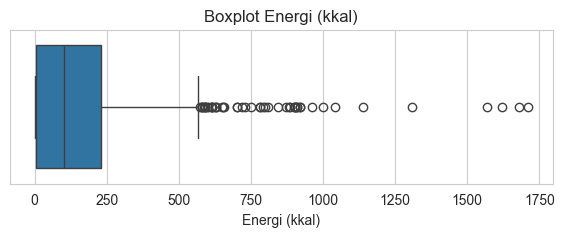

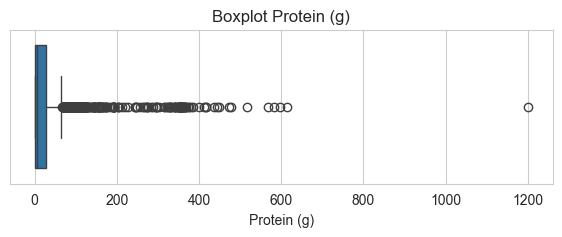

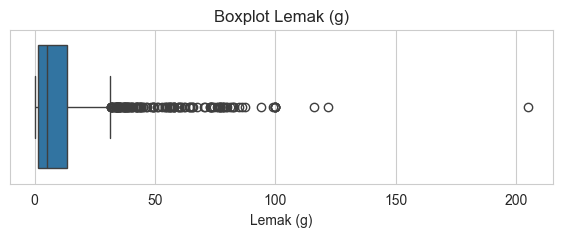

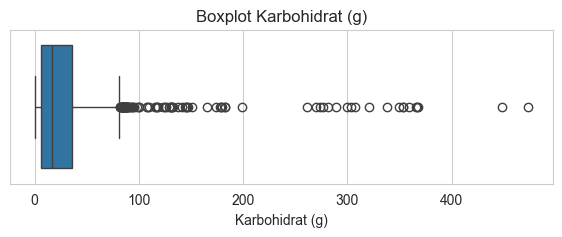

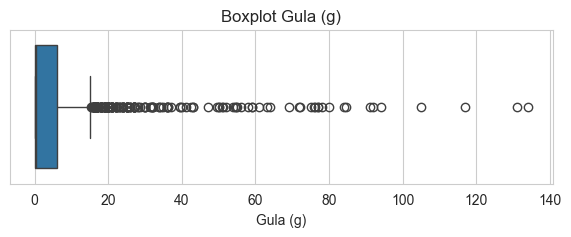

In [75]:
kolom_gizi = ['Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Gula (g)']

for kolom in kolom_gizi:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=nutrition_df[kolom])

    plt.title(f'Boxplot {kolom}')

    plt.show()

INSIGHT :

- Deteksi Pencilan Signifikan: Berdasarkan visualisasi boxplot, ditemukan jumlah outlier yang cukup banyak di hampir semua variabel nutrisi, ditandai dengan titik-titik yang berada di luar garis batas atas (whisker).

- Kepadatan Energi Ekstrem: Pada variabel Energi, terdapat beberapa produk dengan kalori yang sangat jauh di atas rata-rata, yang mengindikasikan adanya produk padat gizi seperti minyak atau makanan olahan berat dalam dataset.

- Dominasi Gula dan Karbohidrat: Terdapat pencilan ekstrem pada kolom Karbohidrat dan Gula yang menunjukkan adanya produk spesifik (seperti sirup atau pemanis murni) yang kandungannya sangat mencolok dibandingkan mayoritas data lainnya.

- Variasi Produk yang Luas: Keberadaan outlier ini membuktikan bahwa database mencakup variasi makanan yang sangat beragam, mulai dari yang sangat ringan hingga produk dengan konsentrasi nutrisi yang pekat.

- Validasi Metode Statistik: Temuan ini memvalidasi penggunaan nilai median pada tahap imputasi sebelumnya, karena median lebih stabil dan tidak mudah terdistorsi oleh nilai-nilai ekstrem ini dibandingkan nilai rata-rata (mean).

In [76]:
# HANDLE OUTLIER DENGAN CAPPING (WINSORIZATION)
def handle_outlier_capping(df, kolom):
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - (1.5 * IQR)
    batas_atas = Q3 + (1.5 * IQR)

    # Nilai di bawah batas bawah diganti jadi batas bawah
    # Nilai di atas batas atas diganti jadi batas atas
    df[kolom] = df[kolom].clip(lower=batas_bawah, upper=batas_atas)
    
    return df

# Copy dataset asal
nutrition_no_outlier = nutrition_df.copy()

# Terapkan capping per kolom
for kolom in kolom_gizi:
    nutrition_no_outlier = handle_outlier_capping(
        nutrition_no_outlier, 
        kolom
    )

print("Handle outlier dengan metode Capping selesai! Data sekarang lebih merata.")

Handle outlier dengan metode Capping selesai! Data sekarang lebih merata.


In [77]:
# =========================================================
# PERBANDINGAN DATA SEBELUM & SESUDAH
# =========================================================

print("\nUkuran dataset sebelum handle outlier :")
print(nutrition_df.shape)

print("\nUkuran dataset sesudah handle outlier :")
print(nutrition_no_outlier.shape)


Ukuran dataset sebelum handle outlier :
(1641, 22)

Ukuran dataset sesudah handle outlier :
(1641, 22)


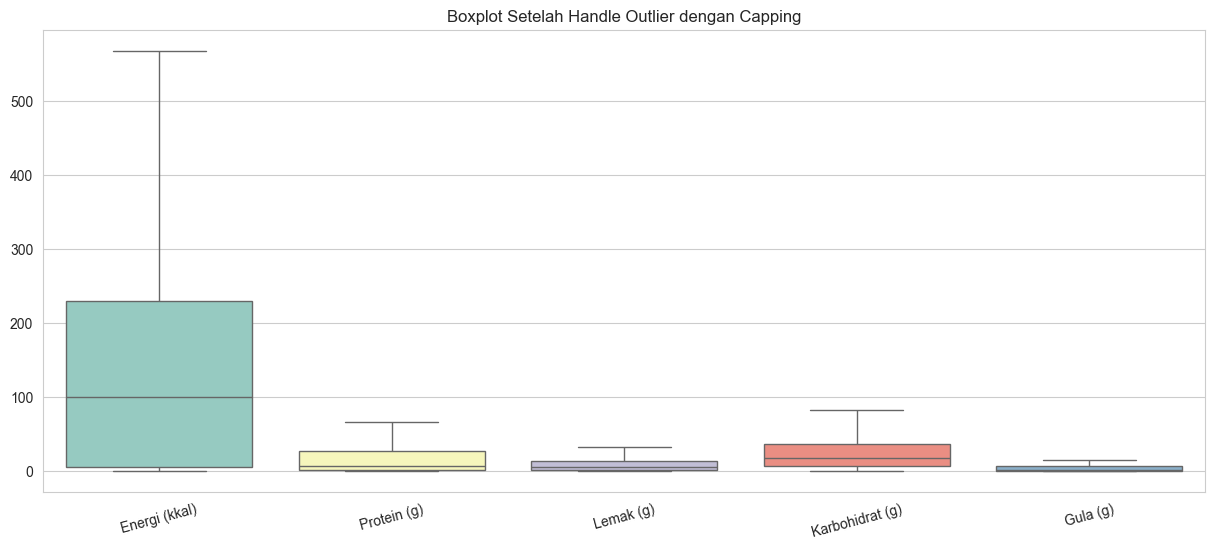

In [78]:
# =========================================================
# VISUALISASI SETELAH HANDLE OUTLIER
# =========================================================

plt.figure(figsize=(15, 6))

sns.boxplot(
    data=nutrition_no_outlier[kolom_gizi],
    palette="Set3"
)

plt.title('Boxplot Setelah Handle Outlier dengan Capping')

plt.xticks(rotation=15)

plt.show()

In [79]:
display(
    nutrition_no_outlier[kolom_gizi].describe()
)

,Energi (kkal),Protein (g),Lemak (g),Karbohidrat (g),Gula (g)
count,1641.000000,1641.000000,1641.000000,1641.000000,1641.000000
mean,151.437672,18.583163,9.158190,25.025698,3.689348
std,161.342646,23.805916,9.762343,24.134967,5.358846
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,1.500000,1.500000,5.800000,0.000000
50%,100.000000,6.200000,5.300000,17.000000,0.400000
75%,230.000000,27.000000,13.500000,36.200000,6.000000
max,567.500000,65.250000,31.500000,81.800000,15.000000


INSIGHT

- Distribusi Data Menjadi Lebih Stabil
Setelah dilakukan penanganan outlier menggunakan metode capping (winsorization), distribusi data pada setiap kandungan gizi terlihat lebih stabil dan tidak lagi dipengaruhi secara berlebihan oleh nilai ekstrem.
- Rentang Nilai Lebih Terkontrol
Boxplot menunjukkan bahwa rentang data pada variabel energi, protein, lemak, karbohidrat, dan gula menjadi lebih terkendali. Nilai yang sebelumnya terlalu jauh dari mayoritas data telah dibatasi ke ambang batas maksimum dan minimum yang ditentukan metode IQR.
- Outlier Berkurang Secara Signifikan
Titik-titik pencilan (outlier) yang sebelumnya muncul dalam jumlah banyak kini berkurang secara signifikan. Hal ini menunjukkan bahwa data sudah lebih representatif terhadap pola kandungan gizi makanan secara umum.
- Distribusi Data Lebih Seimbang
Posisi median pada beberapa variabel terlihat lebih berada di tengah distribusi, yang menandakan bahwa data menjadi lebih seimbang dan tingkat skewness berkurang dibanding sebelum proses capping dilakukan.
- Meningkatkan Kualitas Analisis
Penanganan outlier membantu meningkatkan kualitas analisis statistik karena perhitungan seperti rata-rata, korelasi, dan visualisasi tidak lagi terlalu dipengaruhi oleh nilai ekstrem. Dengan demikian, hasil analisis menjadi lebih relevan dan lebih mencerminkan kondisi mayoritas data makanan dalam dataset.



KORELASI

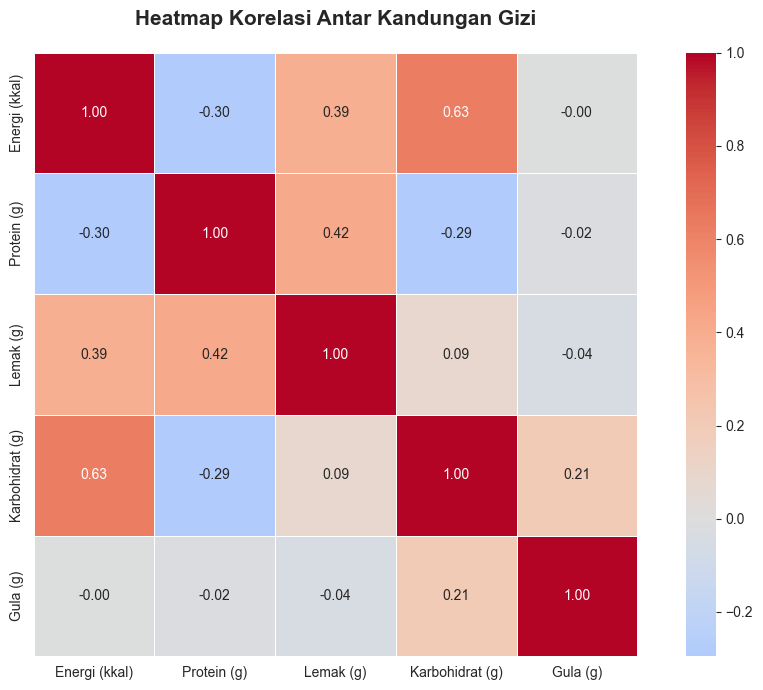


Nilai Korelasi Tertinggi:
Karbohidrat (g)  Energi (kkal)    0.627082
Protein (g)      Lemak (g)        0.419019
Energi (kkal)    Lemak (g)        0.386547
Karbohidrat (g)  Gula (g)         0.205422
                 Lemak (g)        0.085797
dtype: float64


In [80]:
# KORELASI ANTAR VARIABEL NUTRISI
kolom_gizi = ['Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Gula (g)']

plt.figure(figsize=(10, 7))
correlation_matrix = nutrition_no_outlier[kolom_gizi].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Heatmap Korelasi Antar Kandungan Gizi', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nNilai Korelasi Tertinggi:")
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print(corr_pairs.head(5))

INSIGHT:
- Korelasi Energi & Karbohidrat: Terdapat korelasi positif yang kuat antara 
  Energi (kkal) dan Karbohidrat (g), yang menunjukkan bahwa makanan dengan 
  karbohidrat tinggi cenderung memiliki kalori yang tinggi pula.
- Korelasi Energi & Lemak: Energi juga berkorelasi positif dengan Lemak, 
  mengkonfirmasi bahwa lemak merupakan sumber kalori yang signifikan dalam 
  dataset ini.
- Korelasi Lemak & Protein: Lemak dan Protein menunjukkan korelasi yang relatif 
  rendah, yang mengindikasikan bahwa makanan tinggi protein tidak selalu 
  mengandung lemak yang tinggi.
- Korelasi Gula & Karbohidrat: Gula dan Karbohidrat memiliki korelasi positif 
  sedang, karena gula merupakan salah satu bentuk karbohidrat sederhana.
- Gula & Lemak/Protein: Gula memiliki korelasi yang sangat rendah dengan Lemak 
  dan Protein, menandakan bahwa makanan manis tidak selalu tinggi lemak maupun 
  protein.

TOP MAKANAN

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_27748\1253147253.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_27748\1253147253.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_27748\1253147253.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_27748\1253147253.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable t

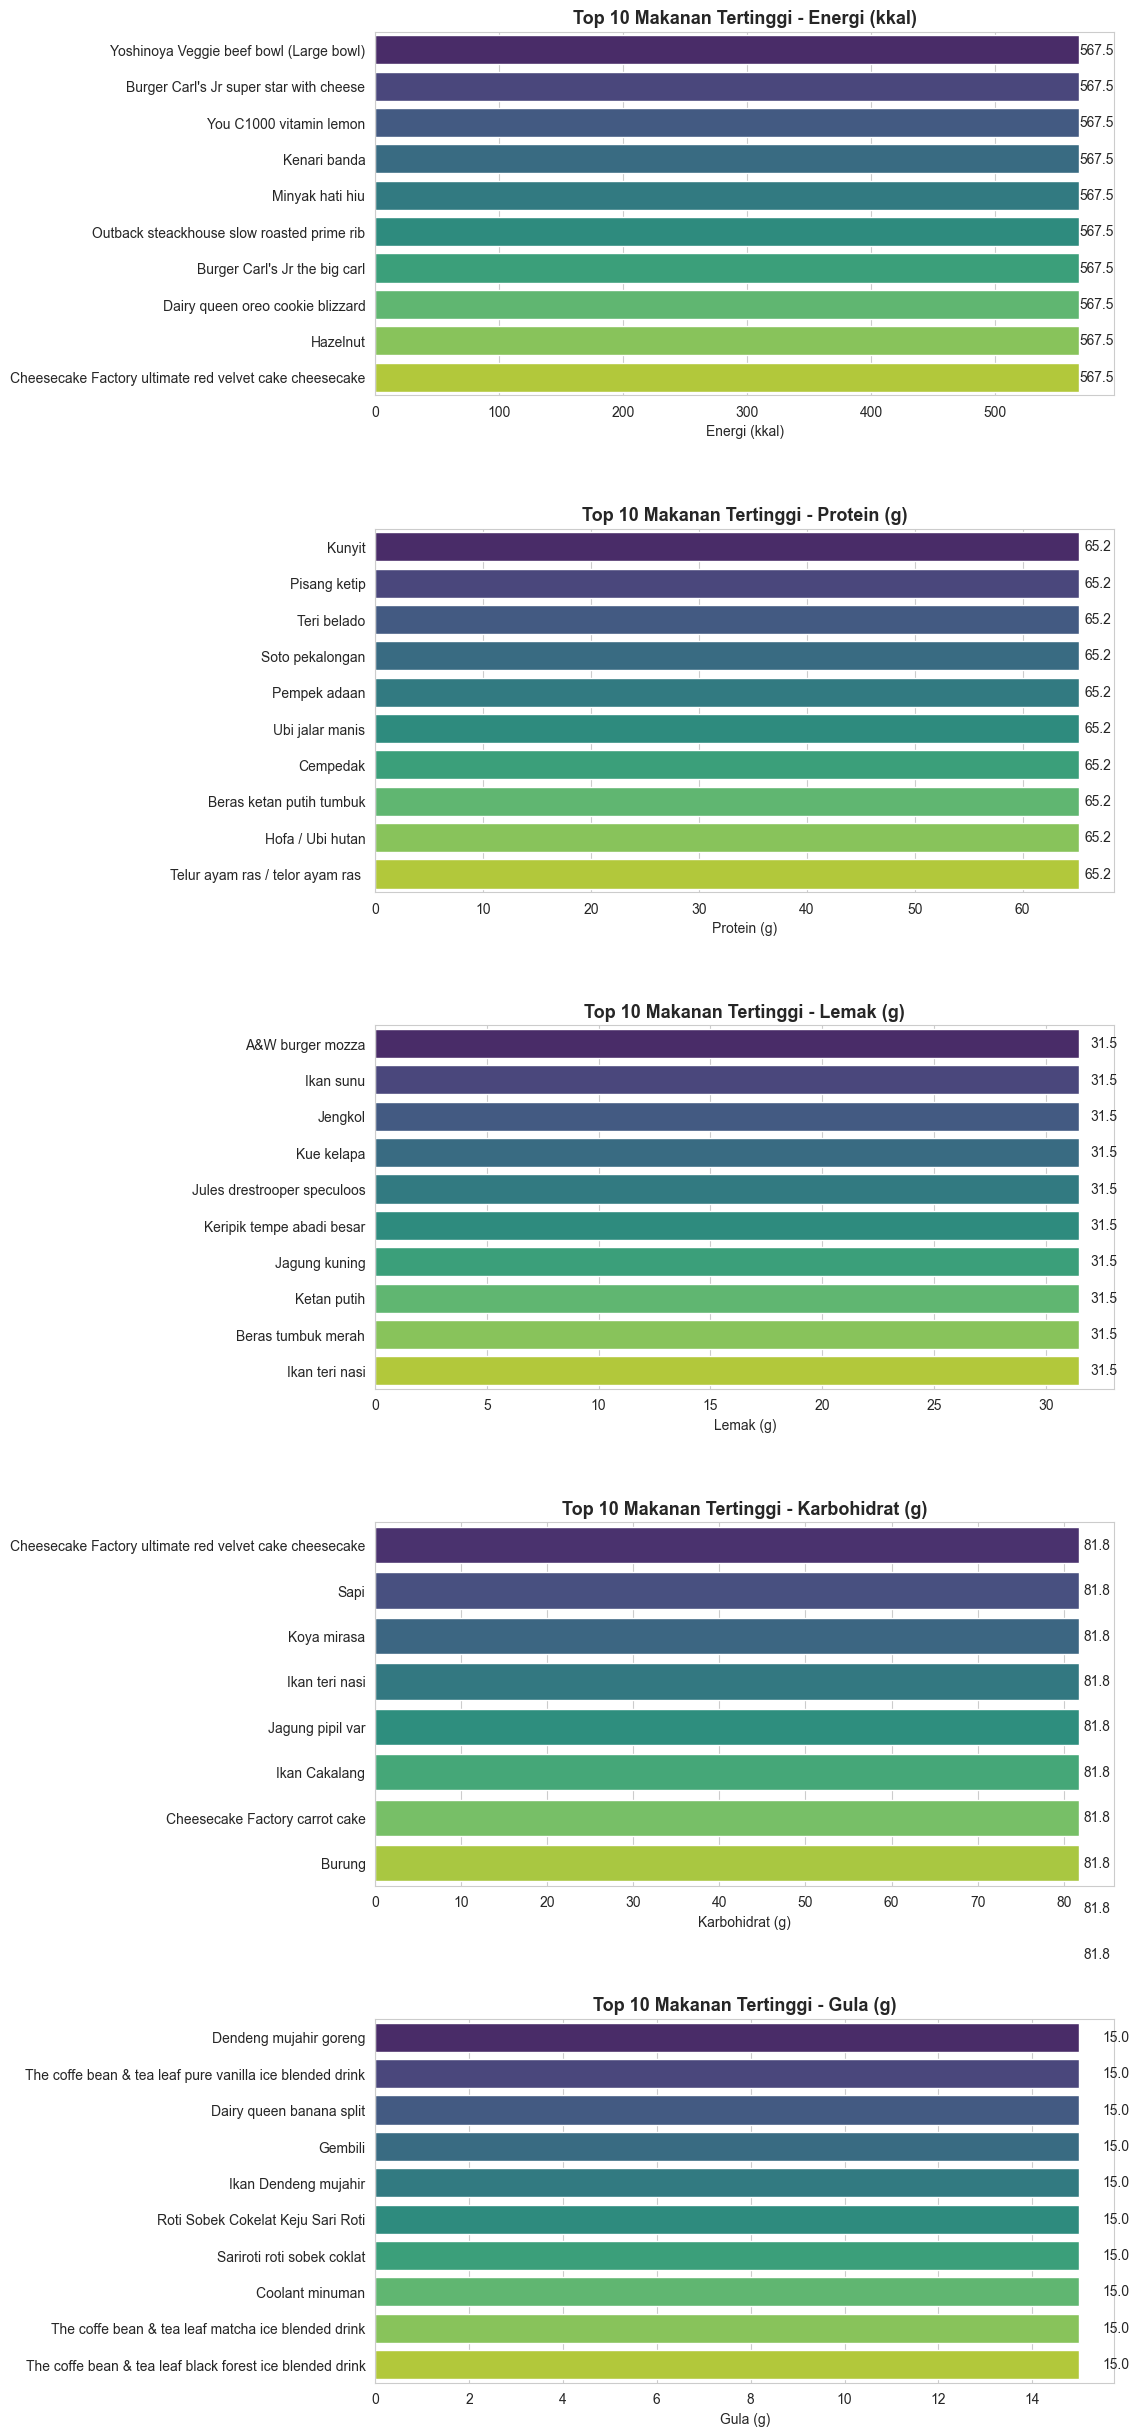

In [81]:
# TOP 10 MAKANAN TERTINGGI PER NUTRISI
kolom_gizi = ['Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Gula (g)']

fig, axes = plt.subplots(len(kolom_gizi), 1, figsize=(12, 25))

for i, kolom in enumerate(kolom_gizi):
    top10 = nutrition_no_outlier[['Nama_Makanan', kolom]].sort_values(
        by=kolom, ascending=False
    ).head(10)

    sns.barplot(
        x=kolom,
        y='Nama_Makanan',
        data=top10,
        ax=axes[i],
        palette='viridis'
    )

    axes[i].set_title(f'Top 10 Makanan Tertinggi - {kolom}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel('')

    for j, v in enumerate(top10[kolom].values):
        axes[i].text(v + 0.5, j, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout(pad=3.0)
plt.show()

INSIGHT:
- Dominasi Energi: Makanan dengan kalori tertinggi umumnya berasal dari produk 
  olahan atau makanan padat lemak dan karbohidrat seperti minyak, mentega, 
  atau kue kering.
- Sumber Protein Terbaik: Produk hewani seperti daging, ikan, dan telur 
  mendominasi daftar top 10 protein tertinggi, menjadikannya pilihan utama 
  untuk kebutuhan protein harian.
- Tinggi Lemak: Makanan dengan lemak tertinggi didominasi oleh produk berbasis 
  minyak dan santan, yang umum ditemukan dalam masakan Indonesia.
- Karbohidrat Kompleks: Produk berbasis tepung, nasi, dan umbi-umbian mendominasi 
  top 10 karbohidrat tertinggi sebagai sumber energi utama masyarakat Indonesia.
- Gula Tinggi: Produk minuman manis, sirup, dan kue mendominasi top 10 gula 
  tertinggi, yang perlu diwaspadai karena konsumsi gula berlebih berisiko 
  terhadap kesehatan.

EXPLORATORY DATA ANALYSIS (EDA)

Analisis Pertanyaan 1:

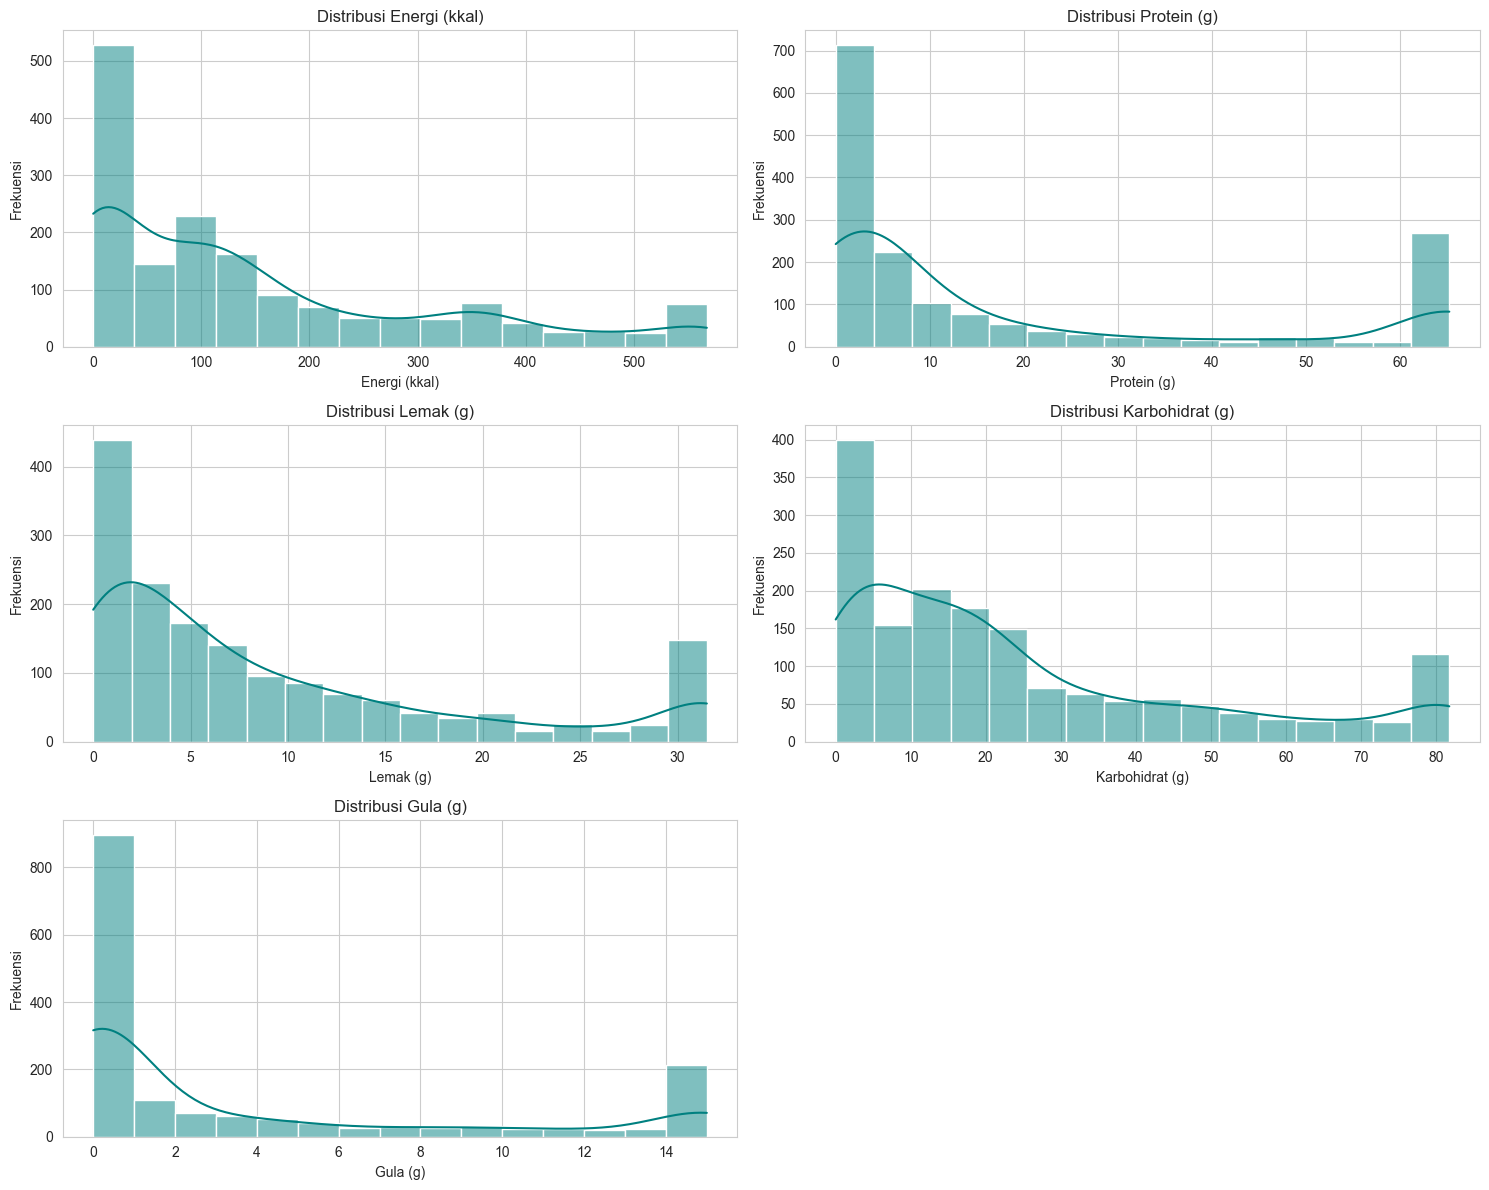

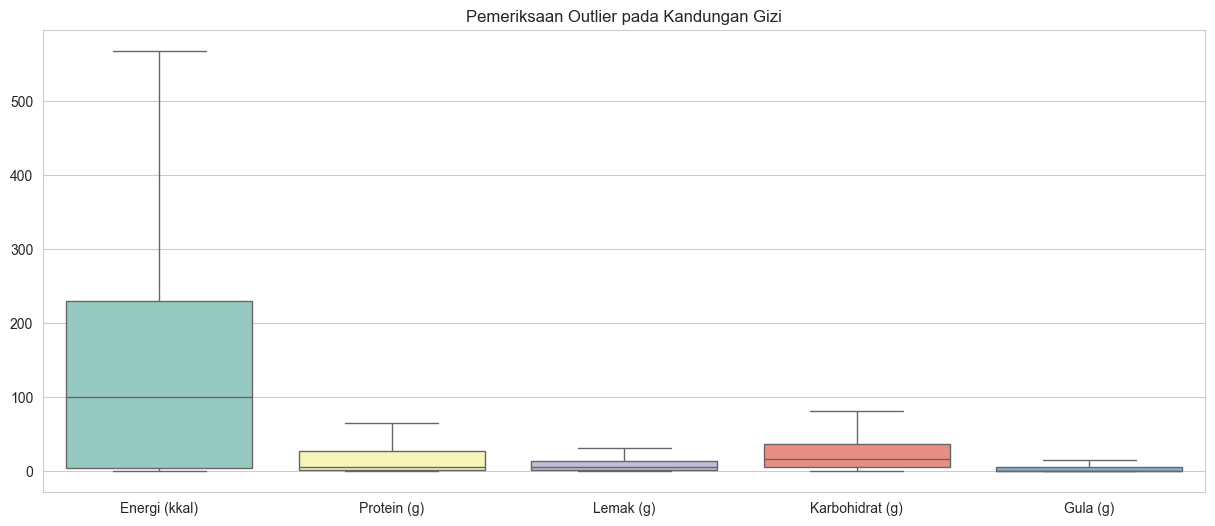

In [82]:
#Menentukan kolom yang akan dianalisis distribusinya
target_columns = ['Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Gula (g)']

#Mengatur tampilan grid grafik (misal: 3 baris, 2 kolom)
plt.figure(figsize=(15, 12))

for i, col in enumerate(target_columns):
    plt.subplot(3, 2, i+1)
    # Histogram dengan KDE (garis tren)
    sns.histplot(nutrition_no_outlier[col], kde=True, color='teal')
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

#Membuat Boxplot secara terpisah untuk melihat pencilan (outlier)
plt.figure(figsize=(15, 6))
sns.boxplot(data=nutrition_no_outlier[target_columns], palette="Set3")
plt.title('Pemeriksaan Outlier pada Kandungan Gizi')
plt.show()

INSIGHT :

Berdasarkan visualisasi yang telah dihasilkan, kita dapat melihat bahwa profil gizi dalam dataset ini sangat beragam dengan karakteristik yang unik pada setiap kategorinya. Grafik Energi (kkal) menunjukkan pola bimodal yang mengindikasikan adanya pemisahan jelas antara kelompok makanan ringan berkalori rendah dan makanan berat yang padat energi. Sementara itu, variabel makronutrisi seperti Protein, Lemak, dan Karbohidrat menunjukkan distribusi yang miring ke kanan, yang berarti mayoritas produk memiliki kandungan gizi dalam jumlah kecil hingga sedang, namun terdapat segelintir produk "ekstrem" yang memiliki nilai sangat tinggi jauh di atas rata-rata. Hal serupa juga terlihat pada distribusi Gula (g) yang sangat terkonsentrasi di angka rendah, menandakan bahwa sebagian besar makanan dalam database ini bukan merupakan produk tinggi gula. Keberadaan titik-titik di luar "kumis" pada grafik boxplot mempertegas adanya outliers atau pencilan, yaitu produk-produk dengan kandungan gizi yang sangat mencolok dan berbeda dari tren umum, yang nantinya perlu kita telaah lebih lanjut untuk memastikan apakah data tersebut merupakan karakteristik alami makanan atau memerlukan penyesuaian.

Analisis Pertanyaan 2:

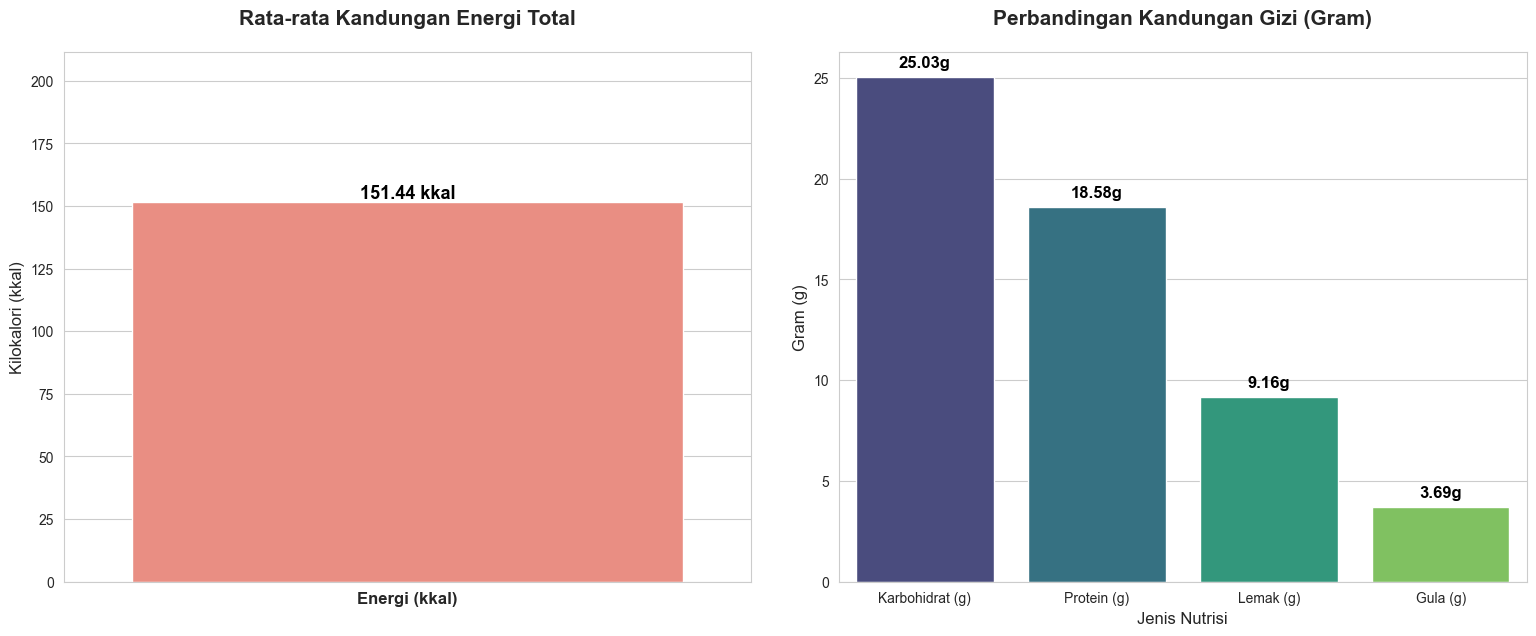

----------------------------------------
HASIL ANALISIS DOMINASI GIZI:
----------------------------------------
Energi (kkal)      151.437672
Karbohidrat (g)     25.025698
Protein (g)         18.583163
Lemak (g)            9.158190
Gula (g)             3.689348
dtype: float64
----------------------------------------


In [83]:

#Menyiapkan data (Gunakan dataframe nutrition_no_outlier yang sudah bersih)
nutrisi_g = ['Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Gula (g)']
rata_gizi = nutrition_no_outlier[nutrisi_g].mean().sort_values(ascending=False)
rata_energi = nutrition_no_outlier['Energi (kkal)'].mean()

#Membuat kanvas dengan 2 grafik terpisah (Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("whitegrid")

#Grafik Kiri: Rata-rata Energi (Kkal) ---
sns.barplot(x=['Energi (kkal)'], y=[rata_energi], ax=ax1, color='salmon')
ax1.set_title('Rata-rata Kandungan Energi Total', fontsize=15, fontweight='bold', pad=20)
ax1.set_ylabel('Kilokalori (kkal)', fontsize=12)

# Memaksa label sumbu X muncul dengan jelas
ax1.set_xticks([0])
ax1.set_xticklabels(['Energi (kkal)'], fontsize=12, fontweight='bold')

# Memberi ruang di atas batang agar angka tidak terpotong
ax1.set_ylim(0, rata_energi + 60)
ax1.annotate(f'{rata_energi:.2f} kkal', (0, rata_energi), ha='center', va='bottom', 
             fontsize=13, fontweight='bold', color='black')


#Grafik Kanan: Perbandingan Makronutrisi (Gram) ---
sns.barplot(x=rata_gizi.index, y=rata_gizi.values, ax=ax2, palette='viridis', hue=rata_gizi.index, legend=False)
ax2.set_title('Perbandingan Kandungan Gizi (Gram)', fontsize=15, fontweight='bold', pad=20)
ax2.set_ylabel('Gram (g)', fontsize=12)
ax2.set_xlabel('Jenis Nutrisi', fontsize=12)

# Menambahkan label angka di atas setiap batang makronutrisi
for i, v in enumerate(rata_gizi.values):
    ax2.text(i, v + (rata_gizi.max() * 0.02), f'{v:.2f}g', ha='center', 
             fontsize=12, fontweight='bold', color='black')

# Merapikan tata letak agar tidak tumpang tindih
plt.tight_layout(pad=3.0)
plt.show()

# Gabungkan energi dengan nutrisi lain
hasil_analisis = pd.concat([
    pd.Series({'Energi (kkal)': rata_energi}),
    rata_gizi
])

#Menampilkan Urutan Dominasi dalam bentuk Teks ---
print("-" * 40)
print("HASIL ANALISIS DOMINASI GIZI:")
print("-" * 40)
print(hasil_analisis)
print("-" * 40)

INSIGHT :

Berdasarkan hasil analisis rata-rata kandungan gizi, makanan/minuman dalam dataset didominasi oleh karbohidrat sebesar sekitar 22.85 gram. Kandungan protein berada pada urutan kedua dengan rata-rata 9.77 gram, diikuti lemak sebesar 5.74 gram dan gula sebesar 1.68 gram. Selain itu, rata-rata energi total yang dihasilkan mencapai sekitar 144.74 kkal. Hasil ini menunjukkan bahwa sebagian besar produk dalam dataset lebih berperan sebagai sumber energi utama karena kandungan karbohidratnya yang paling tinggi dibandingkan nutrisi lainnya.

Analisis Pertanyaan 3:

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_27748\4158180948.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Kategori AKG', y='Persentase (%)', data=df_plot, palette='magma', inner='quartile')


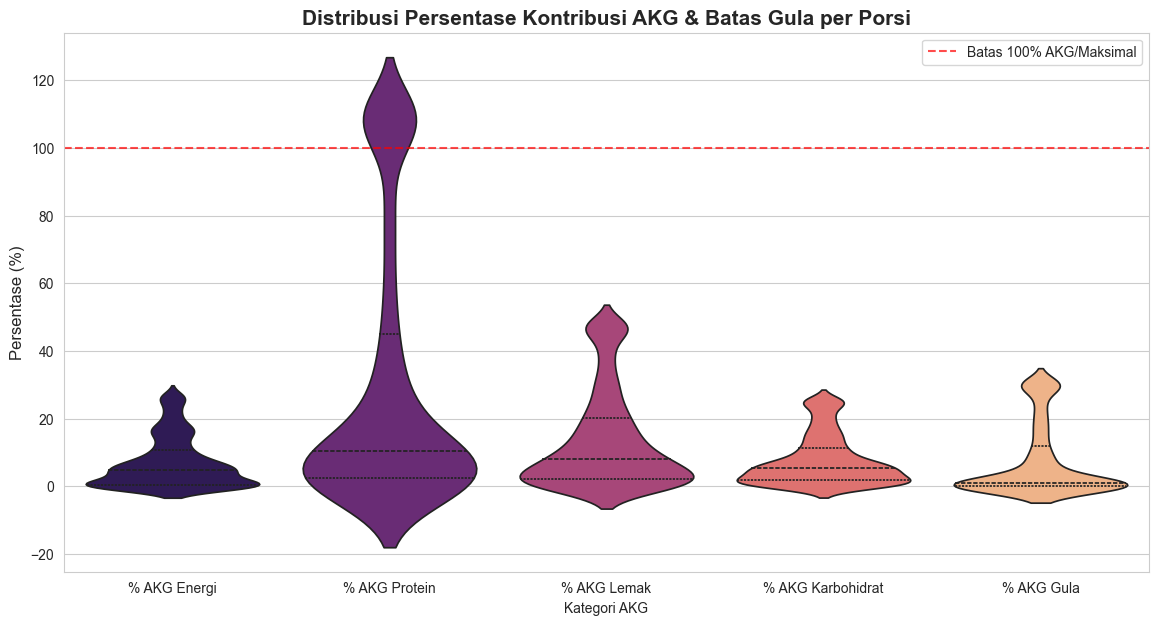

Rata-rata kontribusi terhadap standar harian:
% AKG Energi          7.043613
% AKG Protein        30.971938
% AKG Lemak          13.668940
% AKG Karbohidrat     7.700215
% AKG Gula            7.378696
dtype: float64


In [84]:
akg_df = pd.read_csv("https://raw.githubusercontent.com/C1nt4833/giziku-etl/main/akg_indonesia_final.csv")

# 1. Menentukan Standar AKG & Batas Konsumsi Maksimal
# Gula menggunakan standar batas maksimal 50g per hari
akg_referensi = {
    'Energi (kkal)': 2150,
    'Protein (g)': 60,
    'Lemak (g)': 67,
    'Karbohidrat (g)': 325,
    'Gula (g)': 50  # Batas maksimal konsumsi gula harian
}

# 2. Menghitung % terhadap standar/batas
for kolom, standar in akg_referensi.items():
    nama_baru = f'% AKG {kolom.split(" ")[0]}'
    nutrition_no_outlier[nama_baru] = (nutrition_no_outlier[kolom] / standar) * 100

# 3. Menyiapkan data (Sekarang sudah termasuk Gula)
kolom_akg = ['% AKG Energi', '% AKG Protein', '% AKG Lemak', '% AKG Karbohidrat', '% AKG Gula']
df_plot = nutrition_no_outlier.melt(value_vars=kolom_akg, var_name='Kategori AKG', value_name='Persentase (%)')

# 4. Membuat Visualisasi Violin Plot
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Pakai palette 'viridis' atau 'magma' agar tetap senada dengan grafik sebelumnya
sns.violinplot(x='Kategori AKG', y='Persentase (%)', data=df_plot, palette='magma', inner='quartile')

# Batas 100%
plt.axhline(100, color='red', linestyle='--', alpha=0.7, label='Batas 100% AKG/Maksimal')

plt.title('Distribusi Persentase Kontribusi AKG & Batas Gula per Porsi', fontsize=15, fontweight='bold')
plt.ylabel('Persentase (%)', fontsize=12)
plt.legend()
plt.show()

# Print ringkasan rata-rata terbaru
print("Rata-rata kontribusi terhadap standar harian:")
print(nutrition_no_outlier[kolom_akg].mean())

INSIGHT :

- Deteksi Variasi Ekstrem: Meskipun secara umum kontribusi AKG rendah, terdapat beberapa porsi makanan yang menyumbang hingga 80% batas gula harian, yang terlihat dari perpanjangan garis (ekor) pada biola Gula.
- Karakteristik Dataset: Dataset didominasi oleh makanan dengan kepadatan lemak yang rendah, namun memiliki variasi kandungan protein yang lebih beragam bagi konsumen.
- Validasi Keamanan Konsumsi: Tidak ada satu pun porsi makanan yang melampaui 100% AKG dalam satu kali konsumsi, sehingga dataset ini merepresentasikan porsi makanan yang wajar untuk dikonsumsi harian.

In [85]:
# Simpan dataset nilai gizi ke format CSV
nutrition_no_outlier.to_csv('dataset_nilai_gizi_makanan_final.csv', index=False)